In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("bangladesh_student_performance_updated.csv")

In [4]:
df.shape

(2018, 16)

In [5]:
df.sample(5)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
476,29/04/2018,M,19.0,Urban,GT3,Together,3,1,Health,Health,No,No,99885.0,5,4.30,3.56
1716,29/04/2018,M,17.0,Urban,GT3,Together,3,2,Services,Health,No,Yes,120975.0,5,4.44,3.51
123,29/04/2018,M,19.0,Rural,GT3,Together,3,3,Teacher,Services,No,No,83716.0,4,4.08,3.55
1862,29/04/2018,M,19.0,Urban,LE3,Together,4,2,Teacher,Teacher,No,No,128826.0,1,4.14,3.79
1324,29/04/2018,F,18.0,Urban,GT3,Together,3,1,Other,Farmer,No,No,94546.0,4,4.56,4.07


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [7]:
df['time_friends'].unique()
df['famsize'].unique()

array(['GT3', 'LE3'], dtype=object)

In [8]:
df.isnull().sum()

date             0
gender           0
age             35
address         35
famsize          0
Pstatus          0
M_Edu            0
F_Edu            0
M_Job           35
F_Job            0
relationship     0
smoker           0
tuition_fee     35
time_friends     0
ssc_result       0
hsc_result       0
dtype: int64

In [9]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# Correlation Matrix

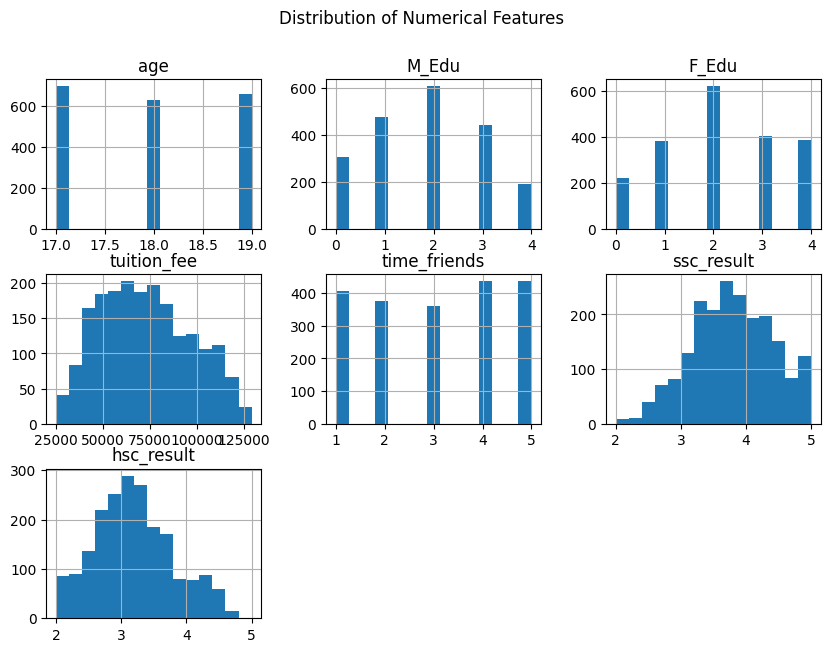

In [11]:
df.hist(bins=15, figsize=(10,7))

plt.suptitle("Distribution of Numerical Features")
plt.show()

In [12]:
numerical_cols = ['age', 'tuition_fee', 'ssc_result', 'hsc_result']
df[numerical_cols].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


# Correlation heatmap and Boxplot

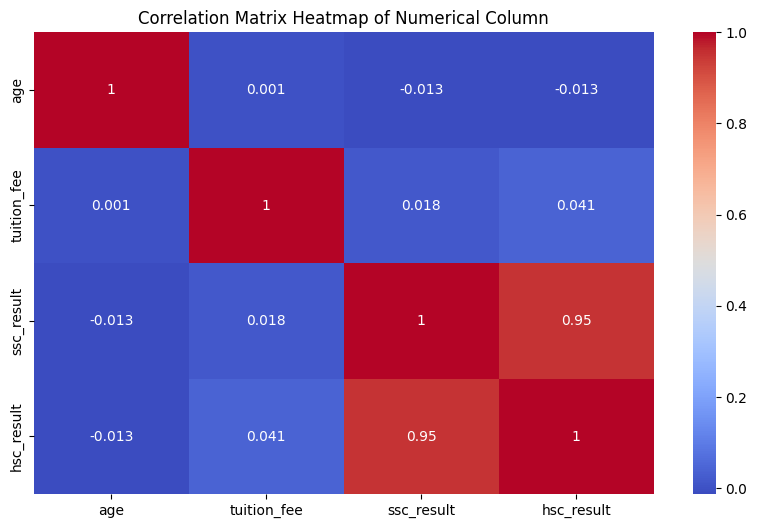

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix Heatmap of Numerical Column")
plt.show()

<Axes: xlabel='ssc_result'>

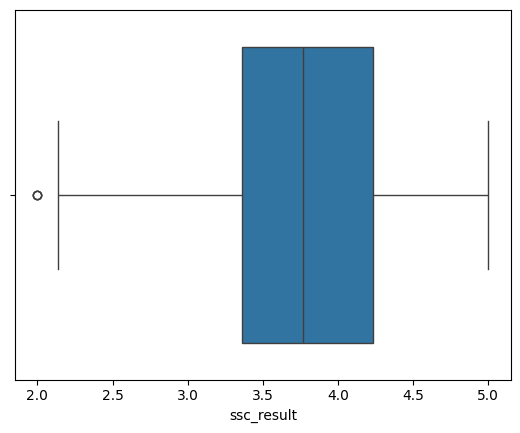

In [14]:
sns.boxplot(data=df, x='ssc_result')

# Pipeline for Transforming Features

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error

In [16]:
nominal_cat = ['gender', 'address', 'famsize', 'Pstatus', 'relationship', 'smoker', 'M_Job', 'F_Job']
# ordinal_cat = ['M_Edu', 'F_Edu', 'time_friends']

# M_edu_order = ['0', '1', '2', '3', '4']
# F_edu_order = ['0', '1', '2', '3', '4']
# time_friends_order = ['5', '4', '3', '2', '1']

numerical_col = ['age', 'tuition_fee', 'ssc_result']

In [17]:
numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)
numerical_transformer

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [18]:
nominal_transformer = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]
)
nominal_transformer

,steps,"[('impute', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [19]:
# ordinal_transformer = Pipeline(
#     steps=[
#         ('impute', SimpleImputer(strategy='most_frequent')),
#         ('encoder', OrdinalEncoder(categories=['M_edu_order', 'F_edu_order', 'time_friends_order'])),
#         ('scaler', MinMaxScaler())
#     ]
# )
# ordinal_transformer

# Pipeline and final model

In [20]:
X = df.drop(['date', 'hsc_result'], axis=1)
y = df['hsc_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Lenear Regration

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformer, numerical_col),
        ('nominal', nominal_transformer, nominal_cat),
        # ('ordinal', ordinal_transformer, ordinal_cat)
    ],
    remainder='passthrough'
)
preprocessor

,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [22]:
lr_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)
lr_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
lr_pipe.predict(X_test)


array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468,
       3.33301608, 3.9843285 , 2.54037997, 1.97886626, 3.27239028,
       3.67549746, 2.91990239, 3.23829796, 4.27797546, 3.03907632,
       2.67683989, 3.71729372, 3.45240833, 2.8064922 , 2.96057683,
       2.82062305, 3.20485147, 2.99957398, 3.21864928, 1.89881831,
       2.58370593, 3.18675035, 3.82959511, 3.08845188, 3.94801852,
       2.39854271, 3.94466671, 4.31696495, 2.56460476, 3.19397834,
       3.26413536, 2.75935124, 3.65848872, 2.48692797, 2.60907848,
       3.07614707, 2.97405288, 3.73760615, 2.76965129, 2.17795697,
       3.0682365 , 2.62107646, 2.60926091, 4.03558054, 3.26099047,
       3.07457897, 3.45268988, 4.23316558, 3.63562822, 3.07047904,
       3.19897028, 3.29199946, 2.67475419, 3.81647227, 2.67135675,
       3.00589862, 2.76737407, 2.49028194, 4.43360442, 2.5597574 ,
       3.21127693, 3.96661533, 2.67087186, 3.03353973, 3.22560591,
       3.03057043, 2.72163419, 2.61374344, 3.63605177, 3.07885

In [24]:
sgd_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SGDRegressor())
    ]
)
sgd_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
sgd_pipe.predict(X_test)

array([3.22901397, 3.78267558, 3.83351376, 3.95089232, 3.85584368,
       3.3414049 , 3.95264406, 2.51706089, 1.97214551, 3.28571368,
       3.68890291, 2.92880252, 3.24200201, 4.27753954, 3.0682881 ,
       2.64233222, 3.73017181, 3.40236715, 2.82991595, 2.93825743,
       2.83478695, 3.21994134, 2.96979181, 3.20615574, 1.91311017,
       2.51467246, 3.21517281, 3.84348177, 3.06866298, 3.95774252,
       2.41114777, 3.97104756, 4.2909369 , 2.58800838, 3.22533771,
       3.28957671, 2.77097193, 3.67939728, 2.49903056, 2.61475295,
       3.10281134, 2.98650216, 3.75276138, 2.77216557, 2.13717519,
       3.08933739, 2.64554285, 2.60759826, 3.99937691, 3.24143766,
       3.06733717, 3.46204212, 4.20639695, 3.63105782, 3.06151175,
       3.16020752, 3.30523272, 2.6700958 , 3.82709406, 2.61408714,
       3.03482518, 2.77755963, 2.48865621, 4.45617475, 2.589484  ,
       3.22071217, 3.94083538, 2.69008994, 3.05383125, 3.21373462,
       3.04107743, 2.73503213, 2.61517466, 3.66202745, 3.08212

# Model Performance

In [26]:
# Lenear Regration
y_pred = lr_pipe.predict(X_test)

print(f"MSE--> {round(mean_squared_error(y_test, y_pred), 4)}")
print(f"R2--> {round(r2_score(y_test, y_pred), 4)}")
print(f"RMSE--> {round(root_mean_squared_error(y_test, y_pred), 4)}")
print(f"MAE--> {round(mean_absolute_error(y_test, y_pred), 4)}")

MSE--> 0.0203
R2--> 0.9459
RMSE--> 0.1425
MAE--> 0.1114


In [27]:
# SGD Regration
y_pred = sgd_pipe.predict(X_test)

print(f"MSE--> {round(mean_squared_error(y_test, y_pred), 4)}")
print(f"R2 score--> {round(r2_score(y_test, y_pred), 4)}")
print(f"RMSE--> {round(root_mean_squared_error(y_test, y_pred), 4)}")
print(f"MAE--> {round(mean_absolute_error(y_test, y_pred), 4)}")

MSE--> 0.0203
R2 score--> 0.9457
RMSE--> 0.1426
MAE--> 0.1119
